# 2620618 - plotting all of our data officially

We want a plot of the simulations, here in jupyter so that we can make a good comparison to Milan's methods. so this is that.

In [1]:
%matplotlib widget 
# from ipywidgets import interact
# import ipywidgets as widgets
# from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker

# basic functions

This is the essence of the transfer matrix stuff at least in the way that Joe originally composed it. This is something that I want to change at some point but it is fine for now.

In [2]:
#3: Basic functions defined for use
def cos(th):
    return np.cos(th*np.pi/180) 
def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 
def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 
def sin(th):
    return np.sin(th*np.pi/180) 

mu0 = 4*np.pi*10**-7

#4: Returns transmitted angle from incident angle. It gives you theta t from theta i. 
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

In [3]:
#5: General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 
def t_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

#6: General form of fresnel coefficients for p polarized light (parrallel electric field)  
def r_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))
def t_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#7: transmission matrix for P poloarized light. It relates the electric field on both sides of an interface. 
def D_p(ni, nt, ki, kt, thi, mui=mu0, mut=mu0):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((1/t_p(ni, nt, ki, kt, thi, mui, mut))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui, mut)],
                                                             [r_p(ni, nt, ki, kt, thi, mui, mut),1]])))  

#8: transmission matrix for S poloarized light. It relates the electric field on both sides of an interface. 
def D_s(ni, nt, ki, kt, thi, mui=mu0, mut=mu0):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((1/t_s(ni, nt, ki, kt, thi, mui, mut))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui, mut)],
                                                             [r_s(ni, nt, ki, kt, thi, mui, mut),1]])))  


#9: propagation matrix that relates electric field on both ends of the same medium. This is independant of polarazation.
def P(ni, nt, ki, kt, thi, d, wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/wavelength),0],
                     [0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/wavelength)]]))


#10: the total fresnell coefficients. Used to relate to total amount of electric field transmitted or reflected in relation to incident electric field. 
# This is currently simulating a two interface system. More can easily be added but updates will need to be made to graphing code and exell file import code. 
def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui, mut) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui, mut) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11)  
def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui, mut) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui, mut) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   
def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui, mut) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui, mut) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 
def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui, mut) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui, mut) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)

def Fresnell_rtot(polarization, i):
    n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
    k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
    wavelength = 1 / wave_numbers[i] # wave_number is in cm^-1 so this makes wavelength in cm which means that d needs to be in cm
    if polarization == 'p':
        return r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)#, t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)
    elif polarization=='s':
        return r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)#, t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)  
    else:
        print('you did not give a correct polarization -- enter s or p')


def wn_to_um(wn):
    return 1e4 / wn

def um_to_wn(um):
    return 1e4 / um



In [16]:
import yaml


def load_refractiveindex_nk_yml(path):
    """
    read a refractiveindex.info yaml file with `tabulated nk` data.

    returns a dataframe with:
        wavelength_um, n, kappa
    """
    with open(path, "r") as f:
        doc = yaml.safe_load(f)

    block = None
    for item in doc["DATA"]:
        if "tabulated nk" in item["type"].lower():
            block = item["data"]
            break

    if block is None:
        raise ValueError("no `tabulated nk` block found in this yaml file")

    arr = np.loadtxt(block.splitlines())

    return pd.DataFrame({
        "wavelength_um": arr[:, 0],
        "n": arr[:, 1],
        "kappa": arr[:, 2],
    })


def add_gold_olmon_to_df(df, yml_path, wavenumber_col="wavenumber"):
    """
    adds olmon evaporated-gold optical constants to df.

    assumes df[wavenumber_col] is in cm^-1.
    """
    au = load_refractiveindex_nk_yml(yml_path)

    # refractiveindex.info table is wavelength in micrometers
    table_wl_um = au["wavelength_um"].to_numpy()
    table_n = au["n"].to_numpy()
    table_kappa = au["kappa"].to_numpy()

    # your ftir axis is probably wavenumber in cm^-1
    wn_cm = df[wavenumber_col].to_numpy(dtype=float)
    target_wl_um = 10000.0 / wn_cm

    # np.interp silently clamps outside the table range, which is dangerous.
    # here we clip intentionally, but print a warning if it happens.
    wl_min = table_wl_um.min()
    wl_max = table_wl_um.max()

    if target_wl_um.min() < wl_min or target_wl_um.max() > wl_max:
        print(
            f"warning: target wavelengths run from "
            f"{target_wl_um.min():.4g} to {target_wl_um.max():.4g} um, "
            f"but table runs from {wl_min:.4g} to {wl_max:.4g} um. "
            f"clipping endpoints."
        )

    target_wl_um_clipped = np.clip(target_wl_um, wl_min, wl_max)

    df = df.copy()
    df["au_wavelength_um"] = target_wl_um
    df["au_n"] = np.interp(target_wl_um_clipped, table_wl_um, table_n)
    df["au_kappa"] = np.interp(target_wl_um_clipped, table_wl_um, table_kappa)
    df["au_n_complex"] = df["au_n"] + 1j * df["au_kappa"]

    return df

# now for plotting all of the Herguadas data

this has been interpolated from their original data, but that is fine

In [17]:
#1: Here is were you upload your excel file. The path depends on your specific computer. to upload a .csv change to pd.read_csv

df = pd.read_excel("./Herguedas-SiOx-interpolated_2.xlsx", sheet_name='OG Data') # nrows avoids extraneous data at the end of each sheet
df.columns = df.columns.str.replace("p", ".", regex=False)

df['n0'] = 1
df['k0'] = 0
df = add_gold_olmon_to_df(
    df,
    "Olmon-ev.yml",
    wavenumber_col="wavenumber",
)

# d is always measured in cm -- 1e-8 cm is 1 angstrom; 10e-8 cm is 1 nanometer
d = 1.65e-8  

# angle is measured in degrees from the normal
th0 = 80 

# setting up other columns that can be helpful
#df['wavelength'] = 1/df['wavenumber']
#df['d'] = d*np.ones(len(df))
#df['th0'] = th0*np.ones(len(df))

In [18]:
df

,wavenumber,wavelength,n0.50,k0.50,n0.55,k0.55,n0.60,k0.60,n0.65,k0.65,...,n1.95,k1.95,n2.00,k2.00,n0,k0,au_wavelength_um,au_n,au_kappa,au_n_complex
0,2000.000000,0.000500,2.703576,-0.000041,2.608729,-0.000045,2.517230,-0.000045,2.429079,-0.000042,...,1.312317,0.001151,1.314563,0.001239,1,0,5.000,3.002579,34.305789,3.002579+ 34.305789j
1,1998.001998,0.000500,2.703576,-0.000041,2.608729,-0.000045,2.517230,-0.000045,2.429079,-0.000042,...,1.312317,0.001151,1.314563,0.001239,1,0,5.005,3.008500,34.340000,3.008500+ 34.340000j
2,1996.007984,0.000501,2.703608,-0.000041,2.608781,-0.000045,2.517299,-0.000045,2.429163,-0.000042,...,1.311837,0.001151,1.314025,0.001239,1,0,5.010,3.014421,34.374211,3.014421+ 34.374211j
3,1994.017946,0.000501,2.703427,-0.000041,2.608509,-0.000045,2.516943,-0.000045,2.428727,-0.000042,...,1.311320,0.001151,1.313582,0.001239,1,0,5.015,3.020342,34.408421,3.020342+ 34.408421j
4,1992.031873,0.000502,2.703063,-0.000041,2.608137,-0.000045,2.516564,-0.000045,2.428344,-0.000042,...,1.311417,0.001151,1.313720,0.001239,1,0,5.020,3.026263,34.442632,3.026263+ 34.442632j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,407.996736,0.002451,2.873967,0.382060,2.814347,0.409236,2.757666,0.434698,2.703924,0.458447,...,2.338096,0.474503,2.363698,0.451989,1,0,24.510,41.945484,135.874194,41.945484+135.874194j
797,405.992449,0.002463,2.883759,0.372697,2.825373,0.398499,2.769757,0.422627,2.716913,0.445079,...,2.315524,0.440874,2.337492,0.418098,1,0,24.631,42.188785,136.342581,42.188785+136.342581j
798,404.007757,0.002475,2.891200,0.362399,2.833752,0.386697,2.778931,0.409378,2.726737,0.430443,...,2.291805,0.410678,2.310543,0.388093,1,0,24.752,42.432086,136.810968,42.432086+136.810968j
799,401.993890,0.002488,2.897205,0.352621,2.840664,0.375381,2.786611,0.396592,2.735046,0.416257,...,2.267723,0.384359,2.283340,0.362241,1,0,24.876,42.681419,137.290968,42.681419+137.290968j


# first i'm going to plot Milan's interpolated n and k data

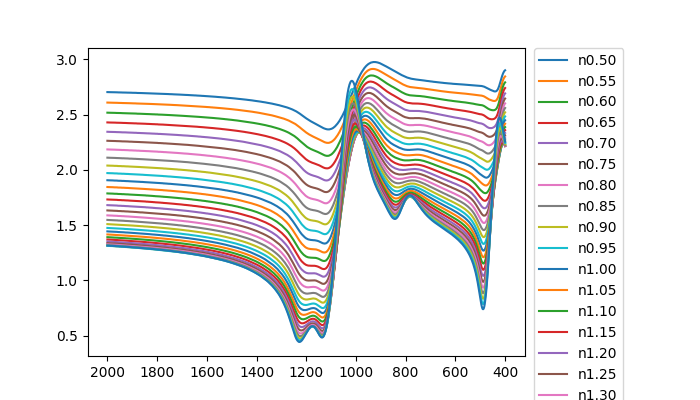

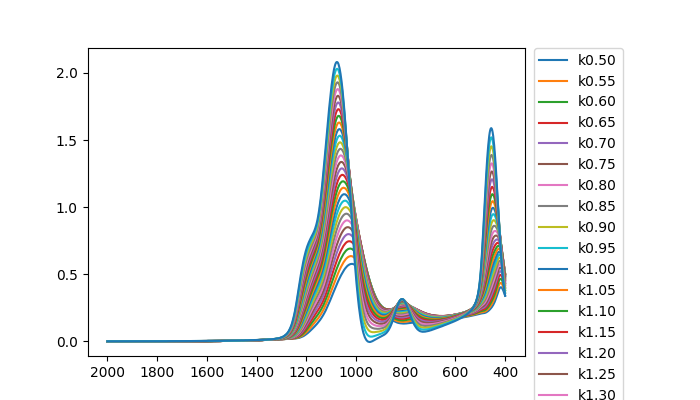

In [6]:
vals = [f"{i:.2f}" for i in np.arange(0.50,2.00+0.05, 0.05)]

ncols = ['n'+v for v in vals]
kcols = ['k'+v for v in vals]

fig_n1, ax_n1 = plt.subplots(figsize=(7, 4))
fig_k1, ax_k1 = plt.subplots(figsize=(7, 4))
ax_n1.plot(df['wavenumber'], df[ncols])
ax_k1.plot(df['wavenumber'], df[kcols])
ax_n1.invert_xaxis()
ax_k1.invert_xaxis()
fig_n1.subplots_adjust(right=0.75)
fig_k1.subplots_adjust(right=0.75)
ax_n1.legend(ncols, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
ax_k1.legend(kcols, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

# now for plotting the absorption data based on these values



In [7]:
df

,wavenumber,wavelength,n0.50,k0.50,n0.55,k0.55,n0.60,k0.60,n0.65,k0.65,...,n1.90,k1.90,n1.95,k1.95,n2.00,k2.00,n0,k0,n2,k2
0,2000.000000,0.000500,2.703576,-0.000041,2.608729,-0.000045,2.517230,-0.000045,2.429079,-0.000042,...,1.313419,0.001065,1.312317,0.001151,1.314563,0.001239,1,0,11,67
1,1998.001998,0.000500,2.703576,-0.000041,2.608729,-0.000045,2.517230,-0.000045,2.429079,-0.000042,...,1.313419,0.001065,1.312317,0.001151,1.314563,0.001239,1,0,11,67
2,1996.007984,0.000501,2.703608,-0.000041,2.608781,-0.000045,2.517299,-0.000045,2.429163,-0.000042,...,1.312994,0.001065,1.311837,0.001151,1.314025,0.001239,1,0,11,67
3,1994.017946,0.000501,2.703427,-0.000041,2.608509,-0.000045,2.516943,-0.000045,2.428727,-0.000042,...,1.312410,0.001065,1.311320,0.001151,1.313582,0.001239,1,0,11,67
4,1992.031873,0.000502,2.703063,-0.000041,2.608137,-0.000045,2.516564,-0.000045,2.428344,-0.000042,...,1.312467,0.001065,1.311417,0.001151,1.313720,0.001239,1,0,11,67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,407.996736,0.002451,2.873967,0.382060,2.814347,0.409236,2.757666,0.434698,2.703924,0.458447,...,2.315433,0.495304,2.338096,0.474503,2.363698,0.451989,1,0,11,67
797,405.992449,0.002463,2.883759,0.372697,2.825373,0.398499,2.769757,0.422627,2.716913,0.445079,...,2.296326,0.461975,2.315524,0.440874,2.337492,0.418098,1,0,11,67
798,404.007757,0.002475,2.891200,0.362399,2.833752,0.386697,2.778931,0.409378,2.726737,0.430443,...,2.275695,0.431646,2.291805,0.410678,2.310543,0.388093,1,0,11,67
799,401.993890,0.002488,2.897205,0.352621,2.840664,0.375381,2.786611,0.396592,2.735046,0.416257,...,2.254595,0.404930,2.267723,0.384359,2.283340,0.362241,1,0,11,67


In [12]:
def singleDataRun(df, d, run):
    cols = ['wavenumber', 'wavelength', f'n{run:.2f}', f'k{run:.2f}', 'n0', 'k0', 'n2', 'k2']
    df0 = df.loc[:, cols].copy()
    df0['rtot'] = np.zeros(len(df), dtype=np.complex128)
    
    # optional: rename selected run to generic names used downstream
    df0 = df0.rename(columns={
        f'n{run:.2f}': 'n1',
        f'k{run:.2f}': 'k1',
    })
    
    for i in df0.index:
        df0.at[i, 'rtot'] = r_p_tot(
            df0.at[i, 'n0'], df0.at[i, 'n1'], df0.at[i, 'n2'],
            df0.at[i, 'k0'], df0.at[i, 'k1'], df0.at[i, 'k2'],
            d, th0, df0.at[i, 'wavelength']
        )
    
    df0['R'] = np.abs(df0['rtot'])**2
    
    r_gold = r_p(
        df0["n0"], df0["n2"],
        df0["k0"], df0["k2"],
        th0
    )
    
    df0["R_gold"] = np.abs(r_gold)**2
    df0["absorbance1"] = -np.log10(df0["R"] / df0["R_gold"])
    #df0['R'] = df0['rtot']*np.conjugate(df0['rtot'])
    #df0['A'] = 1 - df0['R'] # absorbTance
    #baselineA = np.log10(1/df0['A'][0])
    baselineR = np.log10(df0['R'][0])
    #df0['absorbance1'] = -np.log10(df0['A']) - baselineA
    df0['absorbance2'] = np.log10(df0['R']) - baselineR
    
    return(df0)

def singlePlot(df):
    fig, ax = plt.subplots()
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
    ax.set_ylabel('Absorbance') 
    ax.invert_xaxis()
    ax.plot(df.wavenumber, df.absorbance)

    
d_values = np.asarray([0.165,  0.37, 0.46, 0.48, 0.49, 0.54, 0.58, 0.76,  0.85, 0.92, 0.98, 1.055])*10**-7
runs =     [1.25, 1.40, 1.60, 1.95, 2.00, 2.00, 2.00,  2.00,  2.00, 2.00, 2.00, 2.00]


# our data plotted

/tmp/ipykernel_336885/1353664560.py:102: RuntimeWarning: divide by zero encountered in divide
  return 1e4 / um


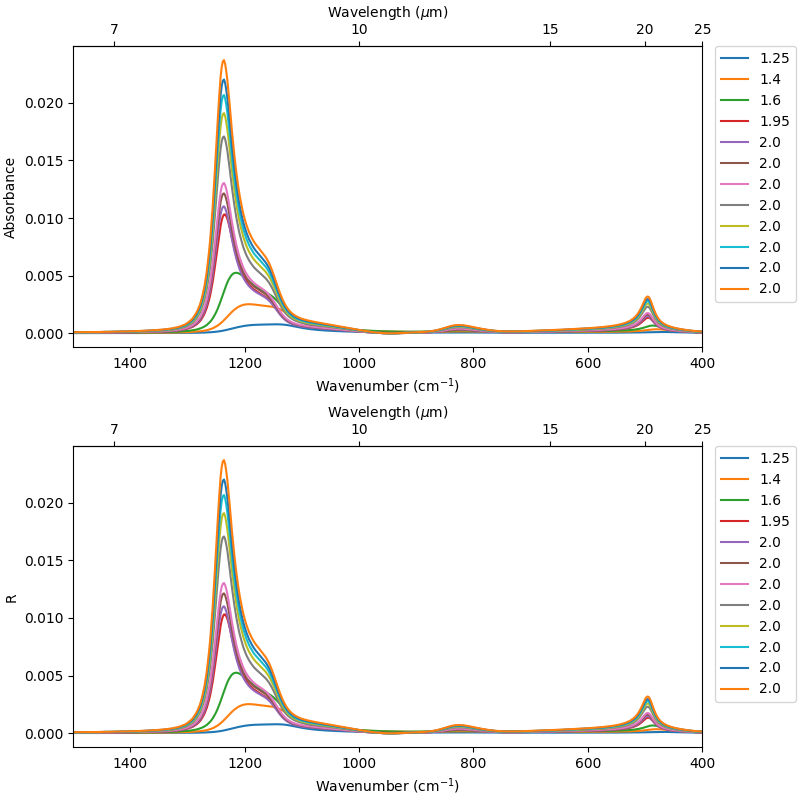

In [13]:
fig, (ax, ax1) = plt.subplots(2, figsize=(8, 8),constrained_layout=True)
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax.set_ylabel('Absorbance') 
#ax.invert_xaxis()
ax1.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax1.set_ylabel('R') 
#ax1.invert_xaxis()

for i in range(0,12):
    d = d_values[i]
    run = runs[i]
    df0 = singleDataRun(df, d, run)
    #ax.plot(df0.wavenumber, df0.absorbance)
    
    ax.plot(df0.wavenumber, df0.absorbance1)

    ax1.plot(df0.wavenumber, df0.absorbance2)

ax.legend(runs)
ax.set_xlim(1500,400)
ax1.legend(runs)
ax1.set_xlim(1500,400)

wave_ticks = [7, 10, 15, 20, 25]   # in microns

for a in (ax, ax1):
    sec = a.secondary_xaxis('top', functions=(wn_to_um, um_to_wn))
    sec.set_xlabel(r'Wavelength ($\mu$m)')
    sec.set_xticks(wave_ticks)
    sec.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:g}'))
    
#secax = ax.secondary_xaxis('top', functions=(wn_to_um, um_to_wn))
#secax.set_xlabel(r'Wavelength ($\mu$m)')
#fig.subplots_adjust(right=0.75)
#fig_k1.subplots_adjust(right=0.75)
ax.legend(runs, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
ax1.legend(runs, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
#fig.tight_layout()

In [15]:
df0

,wavenumber,wavelength,n1,k1,n0,k0,n2,k2,rtot,R,R_gold,absorbance1,absorbance2
0,2000.000000,0.000500,1.314563,0.001239,1,0,11,67,-0.960582-0.155400j,0.946868,0.946862,0.000003,0.000000e+00
1,1998.001998,0.000500,1.314563,0.001239,1,0,11,67,-0.960581-0.155407j,0.946868,0.946862,0.000003,-2.771124e-09
2,1996.007984,0.000501,1.314025,0.001239,1,0,11,67,-0.960579-0.155420j,0.946868,0.946862,0.000003,2.359052e-08
3,1994.017946,0.000501,1.313582,0.001239,1,0,11,67,-0.960577-0.155432j,0.946868,0.946862,0.000003,4.481048e-08
4,1992.031873,0.000502,1.313720,0.001239,1,0,11,67,-0.960576-0.155436j,0.946868,0.946862,0.000003,3.455694e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,407.996736,0.002451,2.363698,0.451989,1,0,11,67,-0.960123-0.159315j,0.947218,0.946862,0.000163,1.605343e-04
797,405.992449,0.002463,2.337492,0.418098,1,0,11,67,-0.960111-0.159343j,0.947203,0.946862,0.000156,1.538632e-04
798,404.007757,0.002475,2.310543,0.388093,1,0,11,67,-0.960100-0.159370j,0.947190,0.946862,0.000151,1.479767e-04
799,401.993890,0.002488,2.283340,0.362241,1,0,11,67,-0.960089-0.159398j,0.947179,0.946862,0.000146,1.430228e-04


# milan's data plotted

/tmp/ipykernel_336885/1353664560.py:102: RuntimeWarning: divide by zero encountered in divide
  return 1e4 / um
/tmp/ipykernel_336885/4213516426.py:11: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


(1500.0, 400.0)

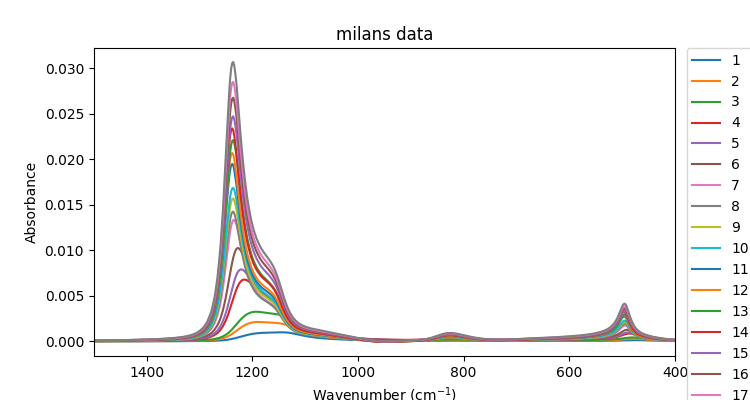

In [14]:
df_milan = pd.read_csv('milanData.csv')
fig1, ax1 = plt.subplots(figsize=(7.5, 4), )
ax1.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax1.set_ylabel('Absorbance') 
ax1.invert_xaxis()
ax1.set_title('milans data')
columns = df_milan.columns[1:]
for i in columns:
    ax1.plot(df_milan['wavenumber'], df_milan[i])
ax1.legend(columns, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.tight_layout()
ax1.set_xlim(1500, 400)

In [158]:
df_milan

,wavenumber,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,400.00,0.000039,0.000064,0.000092,0.000114,0.000108,0.000108,0.000092,0.000087,0.000096,0.000103,0.000106,0.000113,0.000135,0.000127,0.000151,0.000163,0.000174,0.000187
1,401.99,0.000040,0.000067,0.000096,0.000118,0.000113,0.000112,0.000094,0.000089,0.000099,0.000106,0.000109,0.000116,0.000139,0.000131,0.000155,0.000168,0.000179,0.000193
2,404.01,0.000043,0.000070,0.000100,0.000123,0.000117,0.000116,0.000097,0.000092,0.000102,0.000109,0.000113,0.000120,0.000143,0.000135,0.000160,0.000174,0.000185,0.000199
3,405.99,0.000045,0.000073,0.000105,0.000128,0.000122,0.000121,0.000101,0.000096,0.000106,0.000114,0.000117,0.000124,0.000149,0.000140,0.000166,0.000180,0.000192,0.000207
4,408.00,0.000047,0.000077,0.000110,0.000134,0.000127,0.000126,0.000105,0.000100,0.000110,0.000118,0.000122,0.000130,0.000155,0.000147,0.000173,0.000188,0.000200,0.000215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,1992.03,-0.000003,-0.000003,-0.000005,-0.000003,-0.000002,-0.000001,0.000002,0.000002,0.000002,0.000003,0.000003,0.000004,0.000003,0.000004,0.000004,0.000004,0.000004,0.000005
797,1994.02,-0.000003,-0.000003,-0.000005,-0.000003,-0.000002,-0.000001,0.000002,0.000002,0.000002,0.000003,0.000003,0.000004,0.000003,0.000004,0.000004,0.000004,0.000004,0.000005
798,1996.01,-0.000003,-0.000003,-0.000005,-0.000003,-0.000002,-0.000001,0.000002,0.000002,0.000002,0.000003,0.000003,0.000004,0.000003,0.000004,0.000004,0.000004,0.000004,0.000004
799,1998.00,-0.000003,-0.000003,-0.000005,-0.000003,-0.000002,-0.000001,0.000002,0.000002,0.000002,0.000002,0.000003,0.000004,0.000003,0.000004,0.000004,0.000004,0.000004,0.000004
